# 01 - Business and Data Understanding

**SDC Master's Final Project: soccernet-setpiece-vision**
Moritz Philipp Haaf · MSc AI Applied to Sports · Sports Data Campus

**CRISP-DM phases 1 and 2.** This notebook frames the problem and gets to know the data. It establishes *why* broadcast-video Pitch Control matters, *who* it serves, and *what* the ground-truth data looks like building the spatial benchmarks that the later pipeline is measured against.

The analytical ground truth here is StatsBomb 360 freeze-frame data from UEFA Euro 2024: the positions of every visible player at each set piece. Exploring these positions tells us how players actually arrange themselves at corners and free kicks, which is exactly the spatial signal the computer-vision pipeline must reproduce.

## 0. Setup and Imports

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsbombpy import sb
from statsbombpy.api_client import NoAuthWarning
from mplsoccer import Pitch, VerticalPitch

warnings.filterwarnings("ignore", category=NoAuthWarning)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

COMPETITION_ID = 55  # UEFA Euro 2024
SEASON_ID = 282
PITCH_LENGTH_M = 105
PITCH_WIDTH_M = 68
STATSBOMB_X_MAX = 120
STATSBOMB_Y_MAX = 80

# Committed-parquet fast path. This notebook's outputs (setpieces.parquet,
# gt_spatial_benchmarks.parquet) are committed. When they are present we load them
# and skip the live StatsBomb API fetch — the notebook then runs in seconds, offline,
# and deterministically (ideal for graders). When they are absent it falls back to
# the full live fetch from the StatsBomb Open Data API, regenerating identical outputs.
SETPIECES_PATH = OUTPUTS_DIR / "setpieces.parquet"
USE_COMMITTED = SETPIECES_PATH.is_file()

sns.set_theme(style="whitegrid", context="notebook")
print(f"Project root: {PROJECT_ROOT.name}")
print(f"Outputs dir : {OUTPUTS_DIR.relative_to(PROJECT_ROOT)}")
print(f"Data source : {'committed parquets (offline, no API)' if USE_COMMITTED else 'live StatsBomb API'}")

Project root: soccernet-setpiece-vision
Outputs dir : outputs
Data source : committed parquets (offline, no API)


## 1. Business Understanding

**Problem.** Top-tier optical tracking systems (Opta, StatsBomb, SkillCorner) are budget-intensive and effectively exclude second divisions, women's football, youth academies and most scouting contexts. The data gap reinforces a competitive gap.

**Solution.** Derive Pitch Control from broadcast video using a reproducible open-source CV pipeline (Soccana YOLOv11n detection + TVCalib autonomous homography + KMeans HSV team assignment + Laurie Shaw pitch control). Validated against SoccerNet GSR ground-truth player annotations.

**Why set pieces.** Set pieces account for roughly 30 % of tournament goals, the broadcast camera is near-static during execution, all relevant players are typically in frame, and the ball position is fixed and known from the event feed. This makes them the highest-signal, lowest-noise entry point for a CV pipeline.

**Stakeholders.** 2. Bundesliga, Championship, Frauen-Bundesliga, NWSL, academies and scouting departments, i.e. competitions where commercial tracking is unavailable but broadcast video is.

## 2. Data Sources Overview

Three data sources, each with a distinct role in the validation argument:

| Source | Role | What it provides |
|---|---|---|
| **SoccerNet GSR** | Pipeline input + CV ground truth | Broadcast set-piece clips with per-frame player annotations (notebooks 02–03) |
| **StatsBomb 360, Euro 2024** | Analytical ground truth | Freeze-frame coordinates of every visible player at each set piece, across 51 matches |
| **Pipeline output** | The quantity under test | Pitch Control surfaces derived from broadcast frames |

**Validation strategy: distributional, not frame-matched.** SoccerNet GSR clips and StatsBomb Euro 2024 are independent datasets with no shared events, so there is no one-to-one frame correspondence to exploit. Instead we ask a weaker but defensible question: does the *distribution* of Pitch Control values the pipeline produces match the distribution ground truth produces, for the same type of set piece? This notebook builds the ground-truth side of that comparison.

## 3. StatsBomb Euro 2024 Data Loading

We load the StatsBomb 360 dataset for UEFA Euro 2024 (the competition with the richest open freeze-frame coverage) and confirm its scope before extracting set pieces from it.

### 3.1 Competitions

Confirm the competition and season identifiers resolve to UEFA Euro 2024 with 360 data available.

In [2]:
if USE_COMMITTED:
    print("Committed parquets present — skipping StatsBomb competitions fetch.")
    euro_2024 = None
else:
    competitions = sb.competitions()
    euro_2024 = competitions[(competitions["competition_id"] == COMPETITION_ID) & (competitions["season_id"] == SEASON_ID)]
euro_2024

Committed parquets present — skipping StatsBomb competitions fetch.


### 3.2 Matches

Retrieve the full match list (the tournament's 51 fixtures) which defines the universe of set pieces available for analysis.

In [3]:
if USE_COMMITTED:
    print("Committed parquets present — skipping StatsBomb matches fetch.")
    matches = None
else:
    matches = sb.matches(competition_id=COMPETITION_ID, season_id=SEASON_ID)
    print(f"Matches shape: {matches.shape}")
matches.head() if matches is not None else None

Committed parquets present — skipping StatsBomb matches fetch.


### 3.3 Summary

A quick sanity check on the loaded scope: match count, date range, and participating teams, confirming the full tournament is present before extraction.

In [4]:
if USE_COMMITTED:
    print("Match summary skipped (committed-parquet mode — match metadata not refetched).")
else:
    teams = sorted(set(matches["home_team"]).union(matches["away_team"]))
    match_dates = pd.to_datetime(matches["match_date"])
    print(f"Number of matches : {len(matches)}")
    print(f"Date range        : {match_dates.min().date()} -> {match_dates.max().date()}")
    print(f"Total teams       : {len(teams)}")
    print(f"Teams             : {', '.join(teams)}")

Match summary skipped (committed-parquet mode — match metadata not refetched).


## 4. Set-Piece Extraction

From every match we isolate the two set-piece types this project targets (corners and attacking direct free kicks) and attach the 360 freeze frame that records where each player stood at the moment of execution. All coordinates are converted from StatsBomb's 120×80-yard frame to the metric 105×68 m pitch used throughout the project, so the ground truth and the pipeline output share one coordinate system.

In [5]:
def statsbomb_to_metres(x, y):
    """Convert StatsBomb 120x80 yards to 105x68 metres."""
    return x * (PITCH_LENGTH_M / STATSBOMB_X_MAX), y * (PITCH_WIDTH_M / STATSBOMB_Y_MAX)


def convert_freeze_frame_json(frame_list: list) -> list[dict]:
    """Convert raw 360 JSON freeze_frame list to metric player dicts.

    Accepts the list returned by sb.frames(fmt='json') directly (each item has
    keys: location, teammate, actor, keeper). Using fmt='json' avoids the
    statsbombpy 1.18 / pandas 2.x InvalidIndexError in the DataFrame path.
    """
    players = []
    for p in (frame_list or []):
        loc = p.get("location")
        if loc is None:
            continue
        x_m, y_m = statsbomb_to_metres(loc[0], loc[1])
        players.append({
            "player_x_m": float(x_m),
            "player_y_m": float(y_m),
            "teammate": bool(p.get("teammate", False)),
            "actor": bool(p.get("actor", False)),
            "keeper": bool(p.get("keeper", False)),
        })
    return players

### 4.1 - 4.5 Loop over matches

For each match: pull the event stream, keep corners and attacking free kicks, attach the matching 360 freeze frame, convert positions to metres, and accumulate one row per set piece. A freeze frame is only available where StatsBomb captured 360 data, so coverage is tracked as we go.

In [6]:
# Set-piece extraction loop. Robust: explicit per-match diagnostics on
# events/frames failures, retry with backoff for transient statsbombpy errors,
# and a summary of frame-attach success at the end.
# Skipped entirely in committed-parquet mode — setpieces is loaded from the parquet
# in the next cell.

import time

rows = []

if USE_COMMITTED:
    print("Committed-parquet mode — skipping the live set-piece extraction loop.")
else:
    skipped = []
    diag_frames_empty = []
    match_ids = matches["match_id"].tolist()

    def _fetch_with_retry(fn, *, attempts: int = 3, delay: float = 1.0, **kwargs):
        """Call statsbombpy fn(**kwargs) up to N times with linear backoff."""
        last = None
        for k in range(attempts):
            try:
                return fn(**kwargs)
            except Exception as e:
                last = e
                time.sleep(delay * (k + 1))
        raise last

    for i, mid in enumerate(match_ids, 1):
        mid = int(mid)
        try:
            events = _fetch_with_retry(sb.events, match_id=mid)
        except Exception as e:
            skipped.append((mid, f"events: {type(e).__name__}: {e}"))
            continue

        if events is None or events.empty:
            skipped.append((mid, "events empty"))
            continue

        corners = events[(events["type"] == "Pass") & (events.get("pass_type") == "Corner")].copy()
        corners["event_type"] = "corner"

        pass_type_col = events["pass_type"] if "pass_type" in events.columns else pd.Series([None] * len(events), index=events.index)
        shot_type_col = events["shot_type"] if "shot_type" in events.columns else pd.Series([None] * len(events), index=events.index)
        start_x = events["location"].apply(lambda l: l[0] if isinstance(l, list) and len(l) >= 1 else np.nan)
        fk_shot = (events["type"] == "Shot") & (shot_type_col == "Free Kick")
        fk_pass_attacking = (events["type"] == "Pass") & (pass_type_col == "Free Kick") & (start_x >= 80)
        free_kicks = events[fk_shot | fk_pass_attacking].copy()
        free_kicks["event_type"] = "free_kick"

        set_pieces = pd.concat([corners, free_kicks], ignore_index=True)
        if set_pieces.empty:
            continue

        # Use fmt="json" to bypass the statsbombpy 1.18 / pandas 2.x InvalidIndexError
        # that occurs in the DataFrame path due to duplicate indices after explode().
        try:
            frames_raw = _fetch_with_retry(sb.frames, match_id=mid, fmt="json")
        except Exception as e:
            diag_frames_empty.append((mid, f"frames raised: {type(e).__name__}: {e}"))
            frames_raw = None

        if frames_raw is None:
            frames_by_event = {}
        elif not frames_raw:
            diag_frames_empty.append((mid, "frames returned empty list"))
            frames_by_event = {}
        else:
            frames_by_event = {
                f.get("event_uuid", f.get("id")): f.get("freeze_frame", [])
                for f in frames_raw
                if f.get("event_uuid") or f.get("id")
            }

        for _, ev in set_pieces.iterrows():
            loc = ev.get("location")
            if loc is None or (isinstance(loc, float) and np.isnan(loc)):
                continue
            ball_x_m, ball_y_m = statsbomb_to_metres(loc[0], loc[1])
            ev_id = ev.get("id")
            ff_raw = frames_by_event.get(ev_id, [])
            ff = convert_freeze_frame_json(ff_raw) if ff_raw else []
            rows.append({
                "match_id": int(mid),
                "event_id": ev_id,
                "event_type": ev["event_type"],
                "period": int(ev.get("period", 0) or 0),
                "minute": int(ev.get("minute", 0) or 0),
                "second": int(ev.get("second", 0) or 0),
                "team": ev.get("team"),
                "ball_x_m": float(ball_x_m),
                "ball_y_m": float(ball_y_m),
                "freeze_frame": ff,
            })

        if i % 10 == 0:
            n_with_ff_so_far = sum(1 for r in rows if r["freeze_frame"])
            print(f"  processed {i}/{len(match_ids)} matches  |  set pieces: {len(rows)}  |  with FF: {n_with_ff_so_far}")

    n_with_ff_total = sum(1 for r in rows if r["freeze_frame"])
    print(f"\nDone. Total set pieces: {len(rows)}  |  With FF: {n_with_ff_total}  |  Coverage: {100*n_with_ff_total/max(len(rows),1):.1f} %")
    print(f"Matches with frames issue: {len(diag_frames_empty)}  |  Matches fully skipped: {len(skipped)}")
    for mid, why in diag_frames_empty[:5]:
        print(f"  frames-issue {mid}: {why}")
    for mid, why in skipped[:5]:
        print(f"  skipped      {mid}: {why}")

Committed-parquet mode — skipping the live set-piece extraction loop.


### 4.6 Build the cleaned DataFrame

Assemble the accumulated set pieces into a single tidy table (one row per set piece, with ball position and the attached freeze frame) that the rest of the notebook explores.

In [7]:
if USE_COMMITTED:
    setpieces = pd.read_parquet(SETPIECES_PATH)
    print(f"Loaded committed set-pieces: {setpieces.shape}")
else:
    setpieces = pd.DataFrame(rows)
    print(f"Set-pieces frame shape: {setpieces.shape}")
setpieces.head()

Loaded committed set-pieces: (706, 11)


,match_id,event_id,event_type,period,minute,second,team,ball_x_m,ball_y_m,freeze_frame,outcome_10s
0,3930166,99921432-3a5f-40fe-9d9b-08dcfe8b595a,corner,1,5,55,Portugal,105.0,0.085,[],no_shot
1,3930166,2986035c-e88c-479c-a6b6-0d0ba44a8707,corner,1,19,21,Portugal,105.0,0.085,[],shot_on_target
2,3930166,7658870b-706f-4237-bb82-776ccc35f103,corner,1,21,33,Portugal,105.0,68.000,[],shot_off_target
3,3930166,3422371f-2ae4-4959-9fde-5e5ddb8aeaa5,corner,1,21,59,Portugal,105.0,68.000,"[{'player_x_m': 80.91093532979271, 'player_y_m...",no_shot
4,3930166,e759f01d-0dc4-40a8-957f-dbee5c8ccfd3,corner,1,23,53,Portugal,105.0,0.085,[],shot_off_target


## 5. Exploratory Data Analysis

Before modelling, we characterise the set-piece data: how many of each type, where they happen, how many players the freeze frames capture, what tends to follow them, and how players are spatially arranged. The spatial sections (5.6–5.7) are the most important. They define the positional patterns the computer-vision pipeline must reproduce, and produce the benchmark statistics used to judge it in notebook 03.

### 5.1 Set-piece counts

How the cohort splits between corners and direct free kicks - the base rates that determine how much evidence each type contributes to validation.

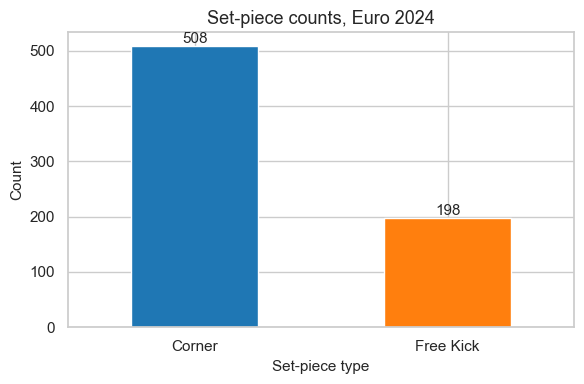

event_type
Corner       508
Free Kick    198
Name: count, dtype: int64


In [8]:
counts = setpieces["event_type"].value_counts()
label_map = {"corner": "Corner", "free_kick": "Free Kick"}
counts.index = counts.index.map(lambda x: label_map.get(x, x.replace("_", " ").title()))
fig, ax = plt.subplots(figsize=(6, 4))
counts.plot(kind="bar", ax=ax, color=["#1f77b4", "#ff7f0e"])
ax.set_title("Set-piece counts, Euro 2024", fontsize=13)
ax.set_xlabel("Set-piece type", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.tick_params(axis="x", rotation=0)
for i, v in enumerate(counts.values):
    ax.text(i, v, str(v), ha="center", va="bottom", fontsize=11)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "01_setpiece_counts.png", dpi=150)
plt.show()
print(counts)


### 5.2 Set-piece locations on a metric pitch

Where on the pitch these set pieces are taken. Corners cluster at the four flag positions and free kicks spread across the attacking half — confirming the events are correctly classified and that ball positions land where they should.

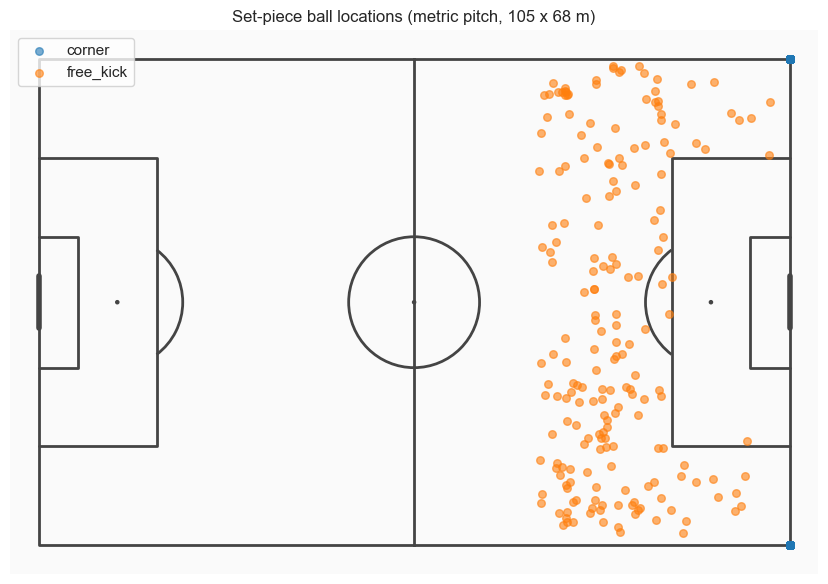

In [9]:
pitch = Pitch(pitch_type="custom", pitch_length=PITCH_LENGTH_M, pitch_width=PITCH_WIDTH_M,
              line_color="#444", pitch_color="#fafafa")
fig, ax = pitch.draw(figsize=(10, 6))
for et, color in [("corner", "#1f77b4"), ("free_kick", "#ff7f0e")]:
    sub = setpieces[setpieces["event_type"] == et]
    pitch.scatter(sub["ball_x_m"], sub["ball_y_m"], ax=ax, s=30, alpha=0.6, color=color, label=et)
ax.legend(loc="upper left")
ax.set_title("Set-piece ball locations (metric pitch, 105 x 68 m)")
fig.savefig(FIGURES_DIR / "02_setpiece_locations.png", dpi=150)
plt.show()

### 5.3 Players visible per freeze frame

How many players each freeze frame captures. This sets the ceiling on spatial completeness: Pitch Control is only as faithful as the number of players positioned on the pitch, so the player count per frame is a direct measure of how rich the ground-truth signal is.

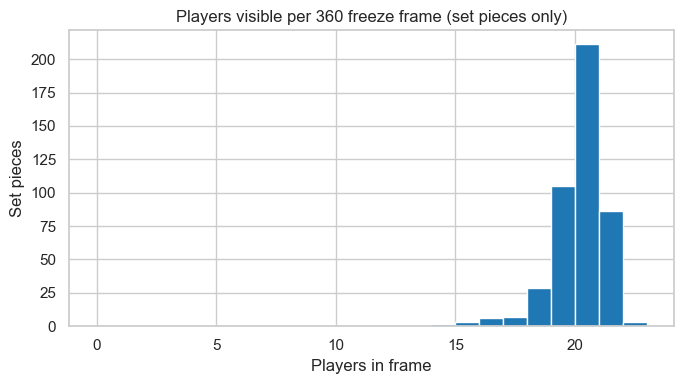

count    706.000000
mean      12.613314
std        9.486641
min        0.000000
25%        0.000000
50%       19.000000
75%       20.000000
max       22.000000
Name: freeze_frame, dtype: float64


In [10]:
ff_counts = setpieces["freeze_frame"].apply(len)
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(ff_counts[ff_counts > 0], bins=range(0, ff_counts.max() + 2), color="#1f77b4", edgecolor="white")
ax.set_title("Players visible per 360 freeze frame (set pieces only)")
ax.set_xlabel("Players in frame")
ax.set_ylabel("Set pieces")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "03_players_per_frame.png", dpi=150)
plt.show()
print(ff_counts.describe())

### 5.4 Freeze-frame coverage

What fraction of set pieces actually carry a freeze frame. Only these events can serve as spatial ground truth, so this coverage figure defines the usable size of the validation cohort.

In [11]:
with_ff = (ff_counts > 0).sum()
without_ff = (ff_counts == 0).sum()
total = len(setpieces)
coverage_pct = 100 * with_ff / total if total else 0
print(f"With freeze frames    : {with_ff}")
print(f"Without freeze frames : {without_ff}")
print(f"Total set pieces      : {total}")
print(f"Coverage              : {coverage_pct:.1f} %")

With freeze frames    : 453
Without freeze frames : 253
Total set pieces      : 706
Coverage              : 64.2 %


### 5.5 Outcomes within 10 seconds after set-piece execution

What actually happens after each set piece: no shot, a shot off target, on target, or a goal within a 10-second window. This grounds the work in football terms: it quantifies how often set pieces create danger, motivating why spatial control at execution is worth measuring in the first place.

Using committed outcome_10s (no StatsBomb refetch).


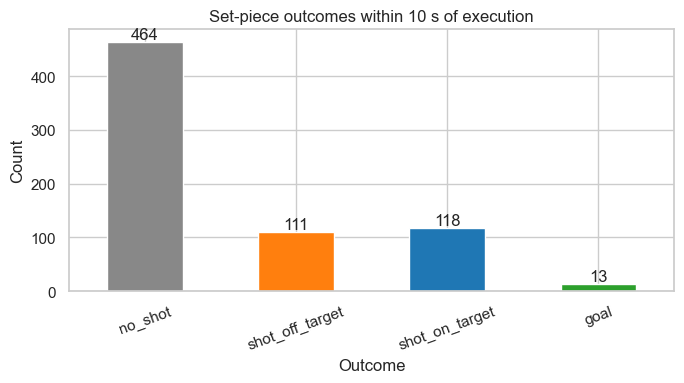

outcome_10s
no_shot            464
shot_off_target    111
shot_on_target     118
goal                13
Name: count, dtype: int64


In [12]:
WINDOW_SEC = 10

def bucket_outcome(events_df: pd.DataFrame, sp_row) -> str:
    t0 = sp_row["period"], sp_row["minute"] * 60 + sp_row["second"]
    sub = events_df[events_df["period"] == t0[0]].copy()
    sub["_t"] = sub["minute"] * 60 + sub["second"]
    window = sub[(sub["_t"] >= t0[1]) & (sub["_t"] <= t0[1] + WINDOW_SEC)]
    shots = window[window["type"] == "Shot"]
    if shots.empty:
        return "no_shot"
    outcomes = shots.get("shot_outcome", pd.Series(dtype=object)).dropna().tolist()
    if any(o == "Goal" for o in outcomes):
        return "goal"
    if any(o in ("Saved", "Saved To Post", "Blocked") for o in outcomes):
        return "shot_on_target"
    return "shot_off_target"


# Committed-parquet mode already carries outcome_10s; otherwise re-fetch events per match.
if USE_COMMITTED and "outcome_10s" in setpieces.columns:
    print("Using committed outcome_10s (no StatsBomb refetch).")
else:
    outcome_buckets = []
    for mid, grp in setpieces.groupby("match_id"):
        try:
            events = sb.events(match_id=int(mid))
        except Exception:
            outcome_buckets.extend(["unknown"] * len(grp))
            continue
        for _, sp in grp.iterrows():
            outcome_buckets.append(bucket_outcome(events, sp))
    setpieces["outcome_10s"] = outcome_buckets

outcome_counts = setpieces["outcome_10s"].value_counts().reindex(
    ["no_shot", "shot_off_target", "shot_on_target", "goal"], fill_value=0
)

fig, ax = plt.subplots(figsize=(7, 4))
outcome_counts.plot(kind="bar", ax=ax, color=["#888", "#ff7f0e", "#1f77b4", "#2ca02c"])
ax.set_title(f"Set-piece outcomes within {WINDOW_SEC} s of execution")
ax.set_xlabel("Outcome")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=20)
for i, v in enumerate(outcome_counts.values):
    ax.text(i, v, str(v), ha="center", va="bottom")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "04_setpiece_outcomes_10s.png", dpi=150)
plt.show()
print(outcome_counts)

### 5.6 Player spatial distribution from freeze frames

Hexbin density maps show where players cluster during corners vs direct free kicks. Expected: corners concentrate players in the penalty area and near posts; free kicks show a defensive wall and scattered attackers at the edge of the box. These patterns motivate the pitch-control analysis in notebook 03.

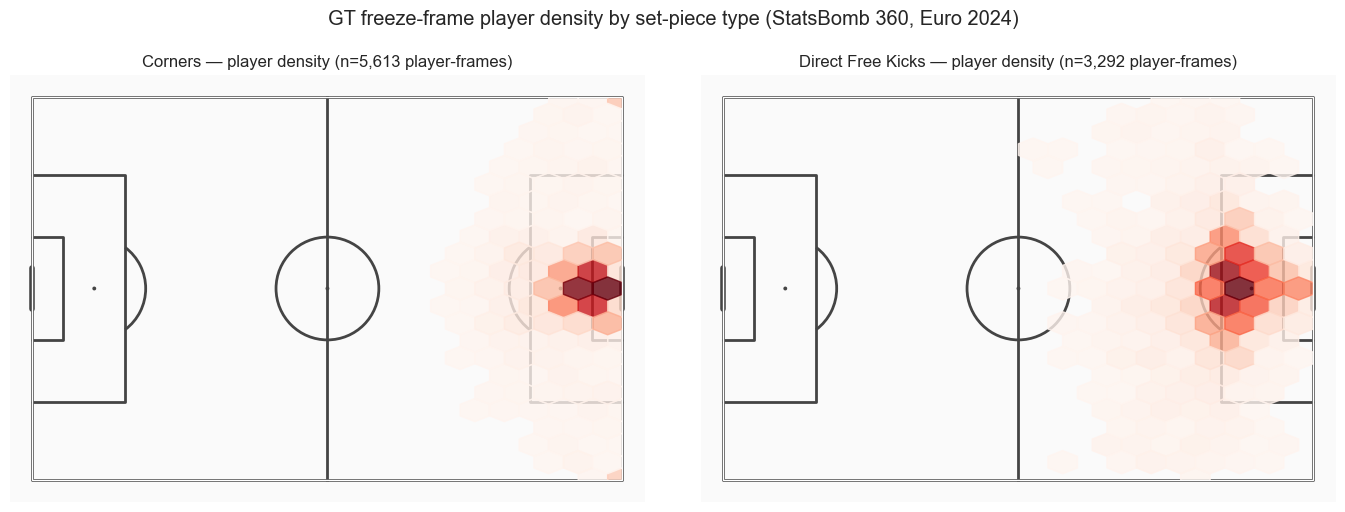

Total player-frame rows : 8,905
  Corners               : 5,613
  Free kicks            : 3,292


In [13]:
# Flatten freeze frames to one row per player
player_rows = []
for _, sp in setpieces[setpieces["freeze_frame"].apply(len) > 0].iterrows():
    for p in sp["freeze_frame"]:
        player_rows.append({
            "event_type": sp["event_type"],
            "player_x_m": p["player_x_m"],
            "player_y_m": p["player_y_m"],
        })
players_df = pd.DataFrame(player_rows)

if players_df.empty:
    print("No freeze frame data — skipping density plot. Check that cell 4 produced Coverage > 0 %.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, et, title in zip(axes, ["corner", "free_kick"], ["Corners", "Direct Free Kicks"]):
        sub = players_df[players_df["event_type"] == et]
        pitch = Pitch(
            pitch_type="custom",
            pitch_length=PITCH_LENGTH_M,
            pitch_width=PITCH_WIDTH_M,
            line_color="#444",
            pitch_color="#fafafa",
        )
        pitch.draw(ax=ax)
        pitch.hexbin(
            sub["player_x_m"], sub["player_y_m"],
            ax=ax, gridsize=20, cmap="Reds", alpha=0.8,
        )
        ax.set_title(f"{title} — player density (n={len(sub):,} player-frames)")

    fig.suptitle(
        "GT freeze-frame player density by set-piece type (StatsBomb 360, Euro 2024)",
        y=1.02,
    )
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "05_player_density_by_setpiece.png", dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Total player-frame rows : {len(players_df):,}")
    print(f"  Corners               : {(players_df['event_type'] == 'corner').sum():,}")
    print(f"  Free kicks            : {(players_df['event_type'] == 'free_kick').sum():,}")

### 5.7 Spatial benchmark statistics

We distil the freeze frames into per-event summary statistics: attacking-third occupancy, lateral compactness, and mean distance to the ball aggregated by set-piece type. These are the quantitative benchmarks of "what correct positioning looks like." Notebook 03 compares the pipeline's reconstructed positions against exactly these numbers, so this section defines the yardstick for the whole validation.

In [14]:
ATK_THIRD_X = PITCH_LENGTH_M * (2 / 3)   # >= 70 m
DEF_THIRD_X = PITCH_LENGTH_M * (1 / 3)   # <= 35 m


def compute_spatial_stats(sp_row: pd.Series) -> dict | None:
    """Per-event spatial summary: occupancy, compactness, dist-to-ball."""
    ff = sp_row["freeze_frame"]
    if ff is None or len(ff) == 0:
        return None
    bx, by = sp_row["ball_x_m"], sp_row["ball_y_m"]
    xs = np.array([p["player_x_m"] for p in ff])
    ys = np.array([p["player_y_m"] for p in ff])
    dists = np.sqrt((xs - bx) ** 2 + (ys - by) ** 2)
    return {
        "event_type": sp_row["event_type"],
        "n_players": len(ff),
        "n_in_atk_third": int((xs >= ATK_THIRD_X).sum()),
        "n_in_def_third": int((xs <= DEF_THIRD_X).sum()),
        "mean_dist_to_ball_m": float(dists.mean()),
        "player_x_std_m": float(xs.std()),
        "player_y_std_m": float(ys.std()),
    }


spatial_rows = [compute_spatial_stats(r) for _, r in setpieces.iterrows()]
spatial_df = pd.DataFrame([r for r in spatial_rows if r is not None])

benchmarks_path = OUTPUTS_DIR / "gt_spatial_benchmarks.parquet"

if spatial_df.empty:
    print("No freeze frame data — spatial benchmarks skipped (Coverage = 0 %).")
    pd.DataFrame().to_parquet(benchmarks_path)
    print(f"Saved empty placeholder: {benchmarks_path.relative_to(PROJECT_ROOT)}")
else:
    benchmarks = (
        spatial_df.groupby("event_type")[
            ["n_players", "n_in_atk_third", "n_in_def_third",
             "mean_dist_to_ball_m", "player_x_std_m", "player_y_std_m"]
        ]
        .agg(["mean", "std"])
        .round(2)
    )
    print("GT spatial benchmarks by set-piece type (mean ± std across events with freeze frames):")
    print(benchmarks.to_string())

    benchmarks.to_parquet(benchmarks_path)
    print(f"\nSaved: {benchmarks_path.relative_to(PROJECT_ROOT)}")

GT spatial benchmarks by set-piece type (mean ± std across events with freeze frames):
           n_players       n_in_atk_third       n_in_def_third      mean_dist_to_ball_m       player_x_std_m       player_y_std_m      
                mean   std           mean   std           mean  std                mean   std           mean   std           mean   std
event_type                                                                                                                             
corner         19.49  1.34          19.49  1.34            0.0  0.0               31.50  1.63           5.30  0.94           9.59  1.30
free_kick      19.95  1.03          19.67  1.61            0.0  0.0               20.61  6.51           5.71  1.27           8.21  2.28

Saved: outputs/gt_spatial_benchmarks.parquet


## 6. Save Output

Persist the two artifacts this phase produces: the cleaned set-piece table and the spatial benchmark statistics. Both feed the modelling and validation in the notebooks that follow.

In [15]:
out_path = OUTPUTS_DIR / "setpieces.parquet"
setpieces.to_parquet(out_path, engine="pyarrow", index=False)
size_mb = out_path.stat().st_size / (1024 * 1024)

n_corner = int((setpieces["event_type"] == "corner").sum())
n_fk = int((setpieces["event_type"] == "free_kick").sum())
n_with_ff = int((setpieces["freeze_frame"].apply(len) > 0).sum())
cov = 100 * n_with_ff / len(setpieces) if len(setpieces) else 0

print(f"Total set pieces extracted   : {len(setpieces)}")
print(f"  Corners                    : {n_corner}")
print(f"  Direct free kicks          : {n_fk}")
print(f"Set pieces with freeze frame : {n_with_ff}")
print(f"Coverage                     : {cov:.1f} %")
print(f"File saved                   : {out_path.relative_to(PROJECT_ROOT)}  ({size_mb:.2f} MB)")
print(f"GT benchmarks saved          : {(OUTPUTS_DIR / 'gt_spatial_benchmarks.parquet').relative_to(PROJECT_ROOT)}")

Total set pieces extracted   : 706
  Corners                    : 508
  Direct free kicks          : 198
Set pieces with freeze frame : 453
Coverage                     : 64.2 %
File saved                   : outputs/setpieces.parquet  (0.21 MB)
GT benchmarks saved          : outputs/gt_spatial_benchmarks.parquet
